## Consultas SQL desde una base Local/on-site SQLite desde jupyter notebook

##### Para fines de pruebas, se utiliza SQLite para crear la base de datos a la que se puedan hacer consultas.
SQLite es una base de datos relacional ligera que se almacena en un solo archivo y no necesita servidor, por lo que es ideal para análisis en local.

#### Luego de crear la base de datos importando la data de las tablas de excel suministradas, se realiza:

##### 1. crear la conexión a la base de datos que tiene el nombre de 'prueba_sql.db'

In [ ]:
import sqlite3
import pandas as pd

# Conecxión a la base de datos
conn = sqlite3.connect("../db/prueba_sql.db")


#### 2. Realizar las querys o consultas de la prueba SQL (para lograr hacer consultas totalmente SQL se cuenta con la extensión Ipython-sql. luego se convierten las consultas a df para ser mostradas con formato pandas (tabla tipo dataframe) y finalmente visualizaciones a través de gráficas con matplotlib):

In [3]:
query = """
SELECT 
    a.nombre AS almacen,
    m.Nombre AS municipio,
    SUM(CAST(c.valorfactura AS INTEGER)) AS valorfactura_total
FROM creditos c
JOIN almacenes a ON c.almacencodigo = a.almacencodigo
JOIN personas p ON c.personacodigo = p.personacodigo
JOIN municipios m ON p.municipiocodigo = m.MunicipioCodigo
GROUP BY a.nombre, m.Nombre
ORDER BY valorfactura_total DESC;
"""

df = pd.read_sql_query(query, conn)

# Mostrar como dataframe la consulta (primeros 10 resultados)
df.head(10)


,almacen,municipio,valorfactura_total
0,ALMACEN_REF_35,Medellin,579171267
1,ALMACEN_REF_10,Medellin,132764672
2,ALMACEN_REF_1,Medellin,111704756
3,ALMACEN_REF_17,Medellin,107345589
4,ALMACEN_REF_41,Medellin,70874560
5,ALMACEN_REF_125,Medellin,68141354
6,ALMACEN_REF_44,Medellin,63629255
7,ALMACEN_REF_18,Medellin,57394632
8,ALMACEN_REF_111,Medellin,54696685
9,ALMACEN_REF_109,Medellin,54578241


<Axes: xlabel='almacen'>

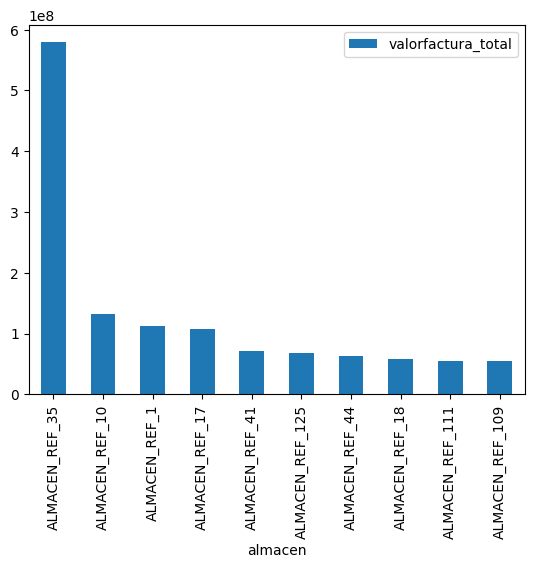

In [4]:

df.head(10).plot(kind='bar', x='almacen', y='valorfactura_total')


#####  valorfactura promedio, la suma de saldocapital y la suma de saldofinanciacion por departamento.

##### Se tiene en cuenta las tablas:
##### . personas para traer el codigo departamento con personacodigo
##### . departamentos para traer el nombre del departamento con departamentocodigo

##### Usando como base la tabla creditos que contiene valorfactura, saldocapital y saldofinanciacion
##### Las funciones de agregación utilizadas son SUM() para sumas y AVG() para promedios.


In [2]:
query = """
SELECT 
    d.Nombre AS departamento,
    AVG(c.valorfactura) AS valorfactura_promedio,
    SUM(c.saldocapital) AS saldocapital_total,
    SUM(c.saldofinanciacion) AS saldofinanciacion_total
FROM creditos c
JOIN personas p ON c.personacodigo = p.personacodigo
JOIN departamentos d ON p.departamentocodigo = d.Codigo
GROUP BY d.Nombre
ORDER BY valorfactura_promedio DESC;
"""

df_departamento = pd.read_sql_query(query, conn)


# Mostrar todos los números en formato normal (float), para evitar notación científica
pd.set_option('display.float_format', '{:,.2f}'.format)


# Mostrar la consulta como dataframe (primeros 10 resultados o filas)
df_departamento.head(10)  



,departamento,valorfactura_promedio,saldocapital_total,saldofinanciacion_total
0,Huila,"8,267,205.00","6,089,848.10","96,080.92"
1,Valle Del Cauca,"3,890,789.50","3,290,490.00","225,502.53"
2,Meta,"3,627,088.00","432,000.00","21,538.30"
3,BogotÃ¡ D.c.,"2,825,108.00","4,153,829.98","217,865.14"
4,Norte De Santander,"2,698,779.00","430,000.00","31,175.74"
5,Risaralda,"2,136,320.60","9,527,211.98","630,580.76"
6,Antioquia,"1,742,258.34","2,454,595,589.42","142,077,690.53"
7,Santander,"1,637,959.89","12,248,328.88","586,580.00"
8,Caqueta,"1,505,847.00","997,692.00","55,348.02"
9,Cesar,"964,520.00","1,843,023.96","126,482.68"


<Axes: xlabel='departamento'>

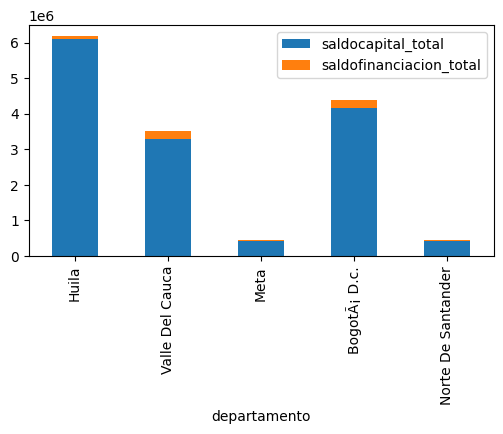

In [3]:
# Ejemplo gráfica barras apiladas para 5 primeros elementos
df_departamento.head(5).plot(
    kind='bar', 
    x='departamento', 
    y=['saldocapital_total','saldofinanciacion_total'], 
    stacked=True, 
    figsize=(6,3)
)



#####  departamento con el valorfactura total más alto.


##### un CTE es una tabla temporal, que se utiliza para que las consultas sean más claras y evitar realizar tantas subconsultas. Se utiliza  WITH para la creación de dicha tabla

##### En este caso se crea la tabla temporal 'totales_por_departamentos.

In [4]:
query = """
WITH totales_por_departamento AS (
    SELECT 
        d.Nombre AS departamento, 
        SUM(c.valorfactura) AS valorfactura_total
    FROM creditos c
    JOIN personas p 
        ON c.personacodigo = p.personacodigo
    JOIN departamentos d 
        ON p.departamentocodigo = d.Codigo
    GROUP BY d.Nombre
)
SELECT 
    departamento,
    valorfactura_total
FROM totales_por_departamento
ORDER BY valorfactura_total DESC
LIMIT 1;
"""


df = pd.read_sql_query(query, conn)

print("Departamento con mayor valorfactura total:")

df



Departamento con mayor valorfactura total:


,departamento,valorfactura_total
0,Antioquia,6812230090


##### 5 almacenes con el mayor porcentaje de créditos de "Alto Riesgo" (donde el saldocapital es mayor al 70% del valorfactura). A parte de mostrar el porcentaje de alto riesgo, se agregan las columnas 'total_credito' y 'creditos_alto_riesgo', para visualizar la razón de por qué son los almacenes con mayor porcentaje de alto riesgo. 

In [5]:

# Conexión a la base de datos
conn = sqlite3.connect("prueba_sql.db")

# Query
query = """
SELECT 
    a.almacencodigo,
    a.nombre AS nombre_almacen,
    COUNT(*) AS total_creditos,
    SUM(
        CASE 
            WHEN c.saldocapital > 0.70 * c.valorfactura THEN 1
            ELSE 0
        END
    ) AS creditos_alto_riesgo,
    ROUND(
        100.0 * SUM(
            CASE 
                WHEN c.saldocapital > 0.70 * c.valorfactura THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS porcentaje_alto_riesgo
FROM creditos c
JOIN almacenes a 
    ON c.almacencodigo = a.almacencodigo
GROUP BY a.almacencodigo, a.nombre
ORDER BY porcentaje_alto_riesgo DESC
LIMIT 5;
"""

# Ejecutar consulta
df = pd.read_sql_query(query, conn)

# Mostrar resultados
df


,almacencodigo,nombre_almacen,total_creditos,creditos_alto_riesgo,porcentaje_alto_riesgo
0,101,ALMACEN_REF_101,1,1,100.00
1,117,ALMACEN_REF_117,1,1,100.00
2,122,ALMACEN_REF_122,1,1,100.00
3,135,ALMACEN_REF_135,1,1,100.00
4,137,ALMACEN_REF_137,1,1,100.00


 valorfactura total por departamento y mes, ordenado por año y mes.

In [6]:

# Query
query = """
SELECT
    d.Codigo AS departamentocodigo,
    d.Nombre AS nombre_departamento,
    strftime('%Y', c.fechacreacion) AS anio,
    strftime('%m', c.fechacreacion) AS mes,
    SUM(c.valorfactura) AS valorfactura_total
FROM creditos c
JOIN personas p 
    ON c.personacodigo = p.personacodigo
JOIN departamentos d 
    ON p.departamentocodigo = d.Codigo
GROUP BY 
    d.Codigo,
    d.Nombre,
    anio,
    mes
ORDER BY 
    anio,
    mes,
    d.Nombre;
"""

# Ejecutar consulta
df = pd.read_sql_query(query, conn)

# Mostrar resultados (10 primeros)
df.head(10)


,departamentocodigo,nombre_departamento,anio,mes,valorfactura_total
0,4,Antioquia,1999,12,158000
1,4,Antioquia,2000,12,3048106
2,4,Antioquia,2001,05,176000
3,4,Antioquia,2002,02,2223532
4,4,Antioquia,2002,08,401400
5,4,Antioquia,2002,09,202000
6,4,Antioquia,2002,10,2217144
7,4,Antioquia,2002,12,217400
8,4,Antioquia,2003,07,5263640
9,4,Antioquia,2003,08,5116160


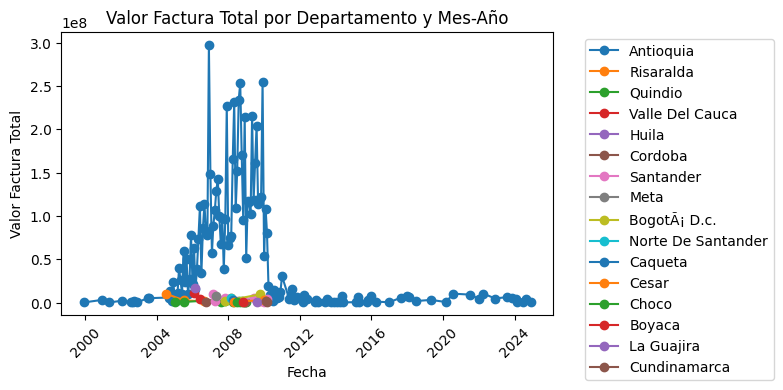

In [7]:

# Crear columna fecha a partir de año y mes
df['fecha'] = pd.to_datetime(df['anio'] + '-' + df['mes'] + '-01')

# Ordenar por fecha
df = df.sort_values(['fecha', 'nombre_departamento'])


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

# ciclo para graficar linea por cada departamento
for depto in df['nombre_departamento'].unique():
    df_depto = df[df['nombre_departamento'] == depto]
    plt.plot(df_depto['fecha'], df_depto['valorfactura_total'], marker='o', label=depto)

plt.title('Valor Factura Total por Departamento y Mes-Año')
plt.xlabel('Fecha')
plt.ylabel('Valor Factura Total')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # leyenda fuera del gráfico
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
